## Load Dataset

In [2]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.append(os.path.abspath('part1'))

from CNNReadCoverage import load_modelCNN, evaluate, CoverageDataset
from DataProcess import load_windows

BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'results')
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Using device: cuda
GPU: NVIDIA GeForce RTX 3080


In [3]:
model, train_losses, val_losses, val_pearson = load_modelCNN()

_, _, test_windows, test_targets = load_windows()

train_max    = 3557.60
test_targets = test_targets / train_max

test_dataset = CoverageDataset(test_windows, test_targets)
test_loader  = DataLoader(test_dataset, batch_size=4096, shuffle=False,
                          num_workers=4, pin_memory=True)

In [4]:
loss_fn = nn.PoissonNLLLoss(log_input=False, full=False)
evaluate(model, test_loader, loss_fn=loss_fn, name='Test (Chr5)')


--- Test (Chr5) Evaluation ---
Poisson loss : 0.000106
Pearson r    : 0.986005


(0.00010569600103314603, np.float64(0.9860049741433622))

## Part 1 Model Comparsion

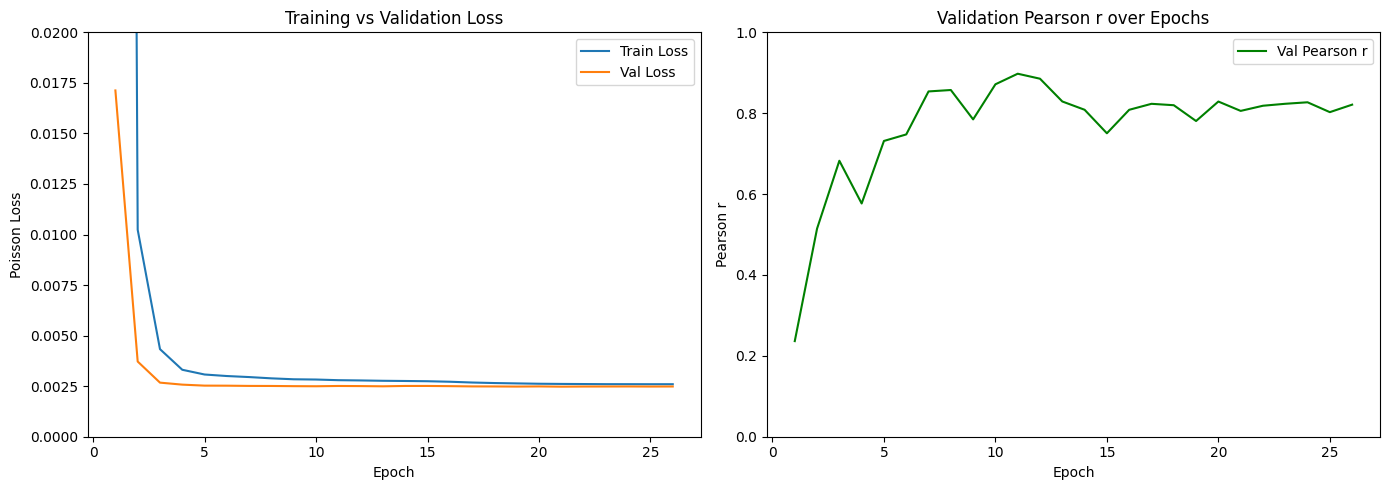

In [5]:
model, train_losses, val_losses, val_pearsons = load_modelCNN()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
ax1.plot(range(1, len(val_losses)   + 1), val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Poisson Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_ylim(0, 0.02)  
ax1.legend()

# Pearson r plot
ax2.plot(range(1, len(val_pearsons) + 1), val_pearsons, label='Val Pearson r', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Pearson r')
ax2.set_title('Validation Pearson r over Epochs')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()